# Notebook 03 — Lucas Critique Analysis

This is the **core experiment**: we investigate whether regime-switching models
are susceptible to the Lucas critique.

## The Lucas Critique in this context

Lucas (1976) argued that econometric models fail under policy changes because
the parameters they estimate are themselves functions of agents' expectations
about policy.  Here we operationalise this by:

1. **Training** all models on pre-break data from a Markov-switching DGP.
2. **Shifting** the DGP parameters (simulating a policy/structural change).
3. **Evaluating** models on post-break data from the new DGP.
4. **Measuring** the Lucas Sensitivity Ratio:

    $$\text{LSR} = \frac{\text{RMSE}_{\text{post}}}{\text{RMSE}_{\text{pre}}}$$

    LSR = 1 means no degradation.  LSR > 1 means Lucas-critique vulnerability.

**Key questions**
- Do classical models (MSM, TAR) have higher LSR than ML models?
- Does the severity of the shift affect the ranking of models?
- Do CUSUM and Chow tests correctly detect the break?

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from simulation import MarkovSwitchingDGP
from simulation.lucas_shift import MILD_SHIFT, SEVERE_SHIFT, simulate_pre_post_break, concatenate_periods
from models import HMMRegimeModel, ThresholdModel, MLRegimeModel, MixtureOfExpertsModel
from evaluation.metrics import (
    forecast_rmse, forecast_mae, directional_accuracy,
    regime_accuracy, adjusted_rand_regime, lucas_sensitivity_ratio,
)
from evaluation.lucas_critique import (
    chow_test, recursive_cusum,
    compute_rolling_performance, compare_pre_post_performance,
)
from evaluation.visualization import (
    plot_lucas_critique_results, plot_rolling_rmse,
    plot_regime_transition_heatmap, save_figure,
)

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')
print('Setup complete.')

Setup complete.


## 1. Full Experiment via Pipeline

In [2]:
from pipeline import LucasCritiqueExperiment

dgp = MarkovSwitchingDGP(seed=42)
experiment = LucasCritiqueExperiment(
    dgp=dgp,
    shift=MILD_SHIFT,
    n_pre=500,
    n_post=250,
    include_msm=True,
    run_chow=True,
)
results = experiment.run(verbose=True)

Lucas Critique Experiment
  DGP: MarkovSwitchingDGP([recession(mu=-0.4, phi=0.7, sigma=1.8), expansion(mu=0.8, phi=0.35, sigma=0.7)], seed=42)
  n_pre=500, n_post=250

[1] Simulating pre-break and post-break samples ...
    Pre-break regime counts : {0: 323, 1: 158}
    Post-break regime counts: {0: 185, 1: 46}

[2] Training and evaluating models on pre-break data ...
  Fitting Markov Switching (MSM) ...
    pre_rmse=1.6732  post_rmse=5.9677  LSR=3.567
  Fitting HMM ...
    pre_rmse=1.6959  post_rmse=2.5592  LSR=1.509
  Fitting Threshold (TAR) ...
    pre_rmse=1.5370  post_rmse=2.5263  LSR=1.644
  Fitting ML Regime (XGB) ...
    pre_rmse=0.3957  post_rmse=3.3369  LSR=8.433
  Fitting Mixture of Experts ...
    pre_rmse=1.3393  post_rmse=2.6280  LSR=1.962
  Fitting MSNN ...
    pre_rmse=0.6128  post_rmse=2.4927  LSR=4.068

[3] Running Chow structural break test ...
    F=13.695, p=0.0000, reject H0=True

[4] Summary
                 model  pre_rmse  post_rmse  pre_mae  post_mae  pre_dir_

## 2. Summary Table

In [3]:
summary = results.summary.copy()
print('\nFull results summary:')
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print(f'\nBest model (lowest LSR): {results.best_model("LSR")}')
print(f'Best regime accuracy (pre-break): {results.best_model("pre_regime_acc")}')


Full results summary:
                 model  pre_rmse  post_rmse  pre_mae  post_mae  pre_dir_acc  post_dir_acc  pre_regime_acc  post_regime_acc  pre_ari  post_ari    LSR
Markov Switching (MSM)    1.6732     5.9677   1.2725    4.6780       0.4437        0.5043          0.7526           0.1991   0.2443    0.0000 3.5665
                   HMM    1.6959     2.5592   1.2933    2.0696       0.5062        0.5348          0.6403           0.7922   0.0756    0.1468 1.5091
       Threshold (TAR)    1.5370     2.5263   1.1846    1.9912       0.5354        0.5870          0.5489           0.6926  -0.0515    0.1381 1.6437
       ML Regime (XGB)    0.3957     3.3369   0.2969    2.5027       0.9042        0.6130          0.6424           0.8182   0.0768    0.2565 8.4328
    Mixture of Experts    1.3393     2.6280   1.0242    2.0312       0.5979        0.5870          0.5759           0.6710  -0.0216    0.0668 1.9622
                  MSNN    0.6128     2.4927   0.3406    1.9009       0.8771        

## 3. Lucas Critique Visualisation

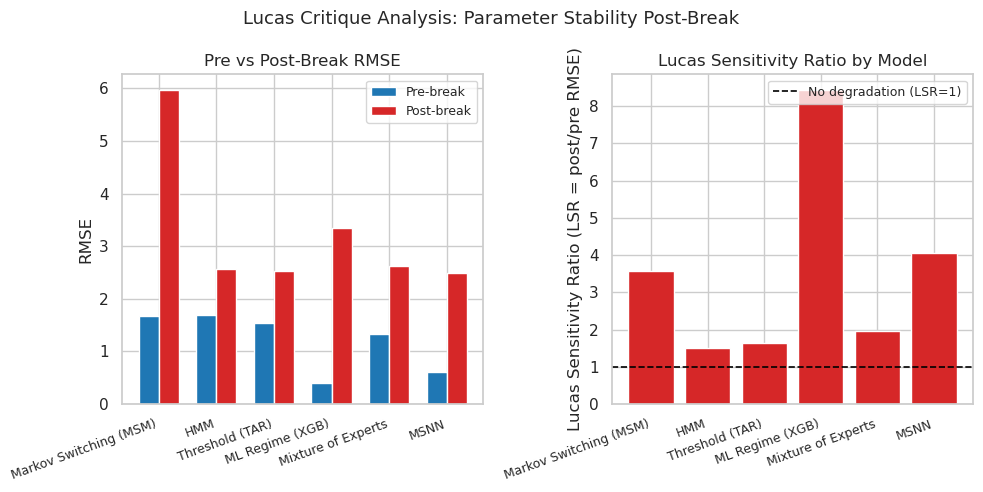

In [4]:
from evaluation.lucas_critique import compare_pre_post_performance

comparison_df = summary[['model', 'pre_rmse', 'post_rmse', 'LSR']]
fig = plot_lucas_critique_results(comparison_df)
save_figure(fig, '03_lucas_critique_results')
plt.show()

## 4. Rolling RMSE: Performance Over Time

In [5]:
# Re-fit models on pre-break, get predictions on full concatenated series
df_pre = results.df_pre
df_post = results.df_post
df_full = concatenate_periods(df_pre, df_post)
break_idx = len(df_pre)

# Fit all models
model_dict = {
    'HMM': HMMRegimeModel(n_components=2, random_state=42),
    'Threshold (TAR)': ThresholdModel(),
    'ML Regime (XGB)': MLRegimeModel(n_regimes=2),
    'Mixture of Experts': MixtureOfExpertsModel(n_experts=2, n_iter=50, random_state=42),
}
try:
    from models import MarkovSwitchingModel
    model_dict['Markov Switching (MSM)'] = MarkovSwitchingModel(k_regimes=2)
except Exception:
    pass

try:
    from models import MarkovSwitchingNeuralNetwork
    model_dict['MSNN'] = MarkovSwitchingNeuralNetwork(
        k_regimes=2,
        hidden_layer_sizes=(32, 16),
        n_iter=50,
        mlp_epochs=200,
        random_state=42,
    )
except Exception as e:
    print(f'MSNN not available: {e}')

full_predictions = {}
for name, model in model_dict.items():
    try:
        model.fit(df_pre)
        # Predict on full series (models generalise out-of-sample via their learned params)
        y_pred_full = model.predict(df_full)
        full_predictions[name] = y_pred_full
        print(f'{name}: predicted {len(y_pred_full)} obs')
    except Exception as e:
        print(f'{name} failed: {e}')

HMM: predicted 712 obs
Threshold (TAR): predicted 712 obs
ML Regime (XGB): predicted 712 obs
Mixture of Experts: predicted 712 obs
Markov Switching (MSM): predicted 712 obs
MSNN: predicted 712 obs


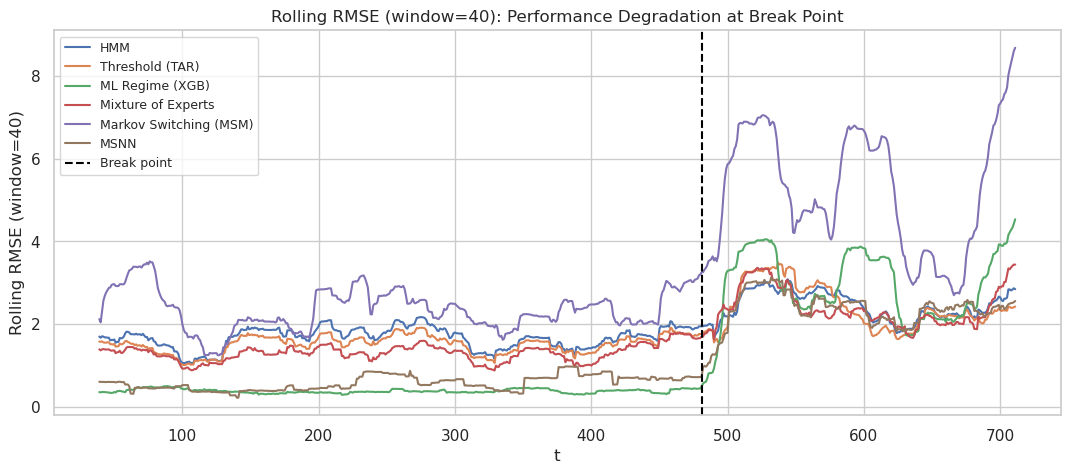

In [6]:
y_full = df_full['y'].to_numpy()
WINDOW = 40

rolling_dict = {}
for name, y_pred in full_predictions.items():
    rolling_dict[name] = compute_rolling_performance(y_full, y_pred, window=WINDOW)

ax = plot_rolling_rmse(rolling_dict, break_index=break_idx, window=WINDOW)
ax.set_title(f'Rolling RMSE (window={WINDOW}): Performance Degradation at Break Point')
save_figure(ax.get_figure(), '03_rolling_rmse')
plt.show()

## 4b. Markov Switching Neural Network (MSNN) — Deep Dive

The **MSNN** combines a K-state hidden Markov chain for regime dynamics with
per-regime MLP regressors, trained jointly via EM:

- **E-step** — Hamilton forward filter + backward smoother (log-space) yields
  smoothed posteriors `γ_t(k) = P(s_t = k | y_{1:T})` and joint posteriors
  `ξ_t(j,k) = P(s_t=j, s_{t+1}=k | y_{1:T})`.
- **M-step** — Transition matrix `A` updated analytically; each MLP expert
  re-fitted with Adam using `γ_t(k)` as per-sample weights.

Prediction uses **Viterbi decoding** to select the most-likely regime path.

In [7]:
from models import MarkovSwitchingNeuralNetwork

msnn = MarkovSwitchingNeuralNetwork(
    k_regimes=2,
    hidden_layer_sizes=(32, 16),
    n_iter=50,
    mlp_epochs=200,
    random_state=42,
)
msnn.fit(df_pre)
print('MSNN fitted.')
print('\nEstimated transition matrix:')
print(msnn.transition_matrix.to_string(float_format='{:.4f}'.format))

# Pre-break metrics
y_pre = df_pre['y'].to_numpy()
pred_pre = msnn.predict(df_pre)
rmse_pre = np.sqrt(np.mean((y_pre - pred_pre) ** 2))

# Post-break metrics
y_post = df_post['y'].to_numpy()
pred_post = msnn.predict(df_post)
rmse_post = np.sqrt(np.mean((y_post - pred_post) ** 2))

lsr = rmse_post / rmse_pre
print(f'\nPre-break  RMSE : {rmse_pre:.4f}')
print(f'Post-break RMSE : {rmse_post:.4f}')
print(f'LSR (post/pre)  : {lsr:.4f}')

MSNN fitted.

Estimated transition matrix:
          regime_0  regime_1
regime_0    0.8560    0.1440
regime_1    0.1244    0.8756

Pre-break  RMSE : 0.6128
Post-break RMSE : 2.4927
LSR (post/pre)  : 4.0679


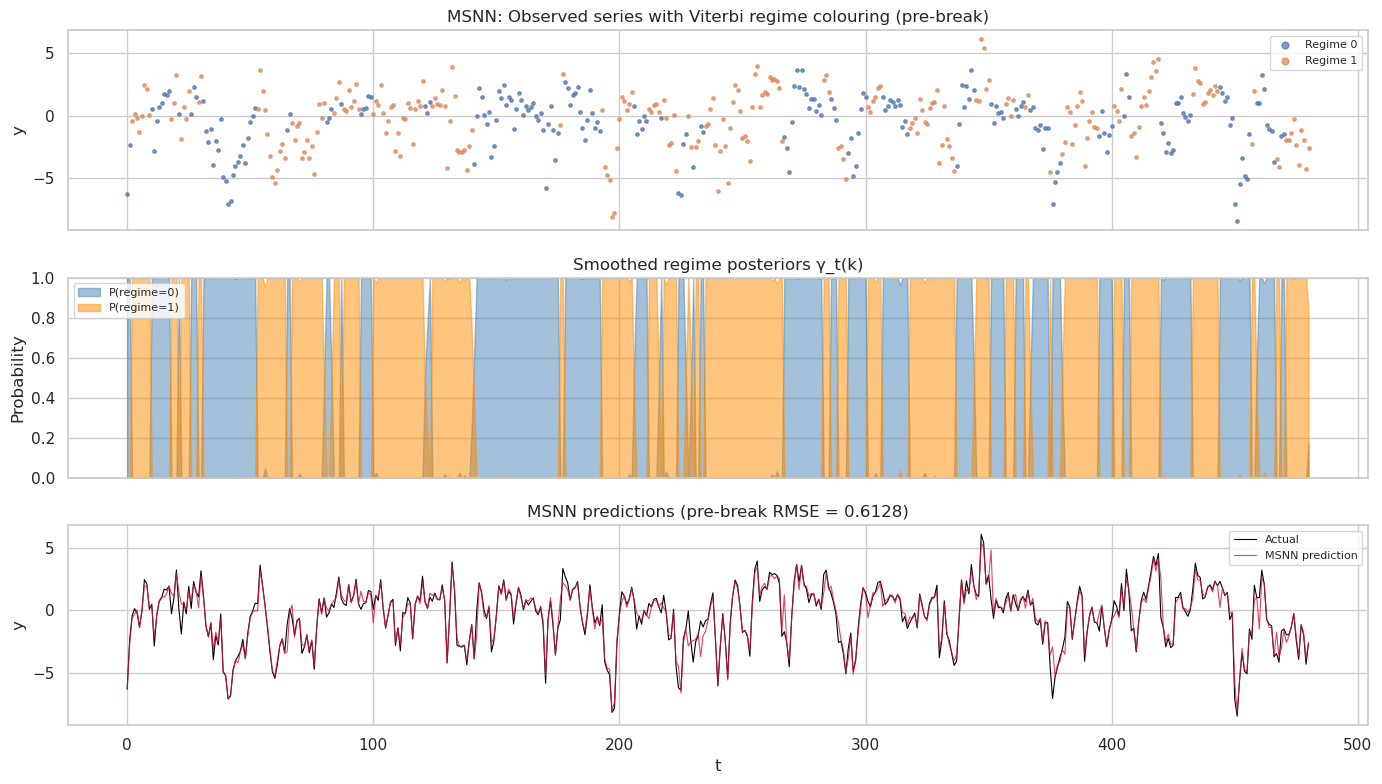

In [8]:
# --- Smoothed regime probabilities over the pre-break training window ---
probs_pre = msnn.regime_probabilities(df_pre)
viterbi_pre = msnn.predict_regimes(df_pre)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

t_pre = np.arange(len(df_pre))

# Panel 1: observed series coloured by Viterbi regime
for k in range(msnn.k_regimes):
    mask = viterbi_pre == k
    axes[0].scatter(t_pre[mask], df_pre['y'].to_numpy()[mask],
                    s=6, alpha=0.7, label=f'Regime {k}')
axes[0].set_ylabel('y')
axes[0].set_title('MSNN: Observed series with Viterbi regime colouring (pre-break)')
axes[0].legend(markerscale=2, fontsize=8)

# Panel 2: smoothed posterior P(s_t = 0 | y_{1:T})
axes[1].fill_between(t_pre, probs_pre['P(regime=0)'], alpha=0.5, color='steelblue',
                      label='P(regime=0)')
axes[1].fill_between(t_pre, probs_pre['P(regime=1)'], alpha=0.5, color='darkorange',
                      label='P(regime=1)')
axes[1].set_ylabel('Probability')
axes[1].set_title('Smoothed regime posteriors γ_t(k)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1)

# Panel 3: one-step-ahead prediction vs actual
axes[2].plot(t_pre, df_pre['y'].to_numpy(), lw=0.8, color='black', label='Actual')
axes[2].plot(t_pre, pred_pre, lw=0.8, color='crimson', alpha=0.8, label='MSNN prediction')
axes[2].set_ylabel('y')
axes[2].set_xlabel('t')
axes[2].set_title(f'MSNN predictions (pre-break RMSE = {rmse_pre:.4f})')
axes[2].legend(fontsize=8)

plt.tight_layout()
save_figure(fig, '03_msnn_regime_probs')
plt.show()

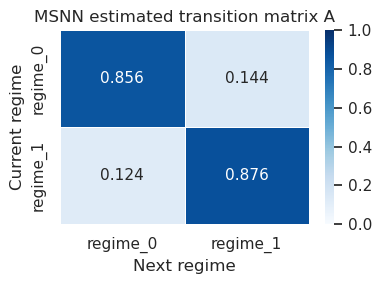

Expected regime durations (1 / (1 - p_stay)):
  Regime 0: p_stay = 0.8560  →  E[duration] ≈ 6.9 periods
  Regime 1: p_stay = 0.8756  →  E[duration] ≈ 8.0 periods


In [9]:
# --- Transition matrix heatmap ---
fig, ax = plt.subplots(figsize=(4, 3))
tm = msnn.transition_matrix
sns.heatmap(
    tm, annot=True, fmt='.3f', cmap='Blues',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 11},
)
ax.set_title('MSNN estimated transition matrix A')
ax.set_xlabel('Next regime')
ax.set_ylabel('Current regime')
plt.tight_layout()
save_figure(fig, '03_msnn_transition_matrix')
plt.show()

# Implied expected regime durations
print('Expected regime durations (1 / (1 - p_stay)):')
for k in range(msnn.k_regimes):
    p_stay = msnn._A[k, k]
    duration = 1.0 / max(1.0 - p_stay, 1e-6)
    print(f'  Regime {k}: p_stay = {p_stay:.4f}  →  E[duration] ≈ {duration:.1f} periods')

                 model  pre_rmse  post_rmse    LSR
                   HMM    1.6959     2.5592 1.5091
       Threshold (TAR)    1.5370     2.5263 1.6437
    Mixture of Experts    1.3393     2.6280 1.9622
Markov Switching (MSM)    2.4332     5.9677 2.4526
                  MSNN    0.6128     2.5024 4.0838
       ML Regime (XGB)    0.3957     3.3369 8.4328


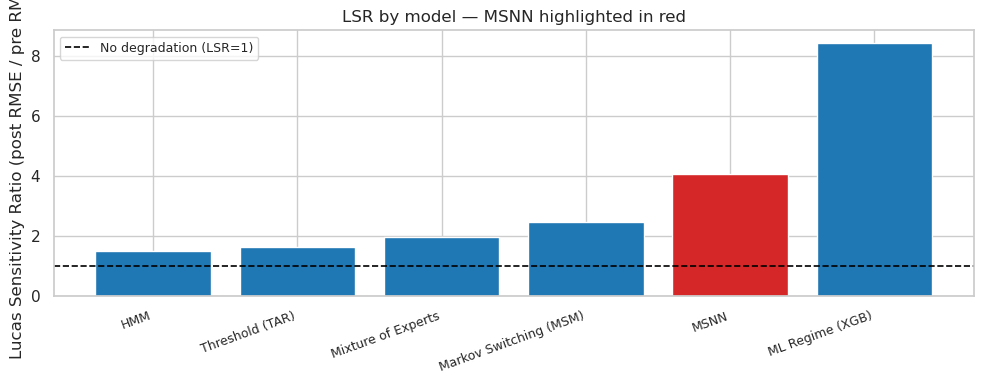

In [11]:
# --- MSNN vs other models: LSR comparison bar chart ---
# Collect LSR for every model that was fit above
lsr_records = []
for name, y_pred in full_predictions.items():
    y_pre_arr = df_pre['y'].to_numpy()
    y_post_arr = df_post['y'].to_numpy()

    n_pre = len(df_pre)
    rmse_pre_m = np.sqrt(np.mean((y_pre_arr - y_pred[:n_pre]) ** 2))
    rmse_post_m = np.sqrt(np.mean((y_post_arr - y_pred[n_pre:]) ** 2))
    lsr_records.append({
        'model': name,
        'pre_rmse': rmse_pre_m,
        'post_rmse': rmse_post_m,
        'LSR': rmse_post_m / max(rmse_pre_m, 1e-9),
    })

lsr_df = pd.DataFrame(lsr_records).sort_values('LSR')
print(lsr_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if m == 'MSNN' else '#1f77b4' for m in lsr_df['model']]
ax.bar(lsr_df['model'], lsr_df['LSR'], color=colors)
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='No degradation (LSR=1)')
ax.set_ylabel('Lucas Sensitivity Ratio (post RMSE / pre RMSE)')
ax.set_title('LSR by model — MSNN highlighted in red')
ax.set_xticklabels(lsr_df['model'], rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, '03_msnn_lsr_comparison')
plt.show()

## 5. Chow Test and CUSUM

In [12]:
if results.chow is not None:
    print('Chow Structural Break Test:')
    for k, v in results.chow.items():
        print(f'  {k}: {v}')
    print()
    if results.chow['reject_H0']:
        print('Conclusion: The Chow test REJECTS parameter stability (structural break detected).')
    else:
        print('Conclusion: The Chow test FAILS TO REJECT parameter stability.')

Chow Structural Break Test:
  F_stat: 13.694624258092698
  p_value: 1.4610244000179406e-06
  df1: 2
  df2: 708
  reject_H0: True

Conclusion: The Chow test REJECTS parameter stability (structural break detected).


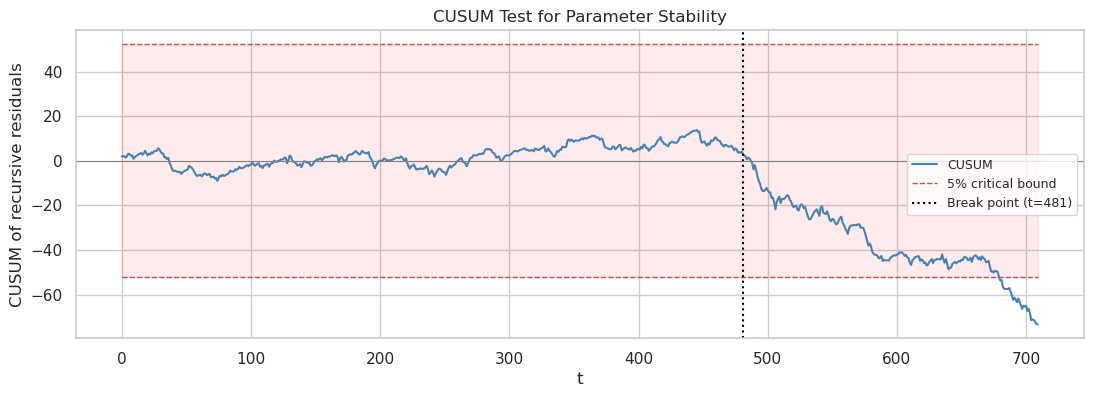

Break detected: True
First exit from band at index: 680


In [13]:
# CUSUM test on the concatenated AR(1) residuals
y_full_arr = df_full['y'].to_numpy()
X_full = df_full[['y_lag1']].assign(const=1.0)[['const', 'y_lag1']].to_numpy()

cusum_result = recursive_cusum(y_full_arr, X_full)

fig, ax = plt.subplots(figsize=(13, 4))
t_cusum = np.arange(len(cusum_result['cusum']))
ax.plot(t_cusum, cusum_result['cusum'], color='steelblue', lw=1.5, label='CUSUM')
ax.plot(t_cusum, cusum_result['upper_bound'], 'r--', lw=1, label='5% critical bound')
ax.plot(t_cusum, cusum_result['lower_bound'], 'r--', lw=1)
ax.fill_between(t_cusum, cusum_result['lower_bound'], cusum_result['upper_bound'],
                alpha=0.08, color='red')
ax.axvline(break_idx, color='black', ls=':', lw=1.5, label=f'Break point (t={break_idx})')
ax.axhline(0, color='gray', lw=0.7)
ax.set_xlabel('t')
ax.set_ylabel('CUSUM of recursive residuals')
ax.set_title('CUSUM Test for Parameter Stability')
ax.legend(fontsize=9)
save_figure(fig, '03_cusum_test')
plt.show()

print(f'Break detected: {cusum_result["break_detected"]}')
if cusum_result['break_index'] is not None:
    print(f'First exit from band at index: {cusum_result["break_index"]}')

## 6. Severe Shift Comparison

In [14]:
print('Running experiment with SEVERE Lucas shift...')
exp_severe = LucasCritiqueExperiment(
    dgp=MarkovSwitchingDGP(seed=42),
    shift=SEVERE_SHIFT,
    n_pre=500,
    n_post=250,
    include_msm=True,
)
results_severe = exp_severe.run(verbose=False)

print('\nMild shift LSRs:')
print(summary[['model', 'LSR']].to_string(index=False, float_format='{:.3f}'.format))
print('\nSevere shift LSRs:')
print(results_severe.summary[['model', 'LSR']].to_string(index=False, float_format='{:.3f}'.format))

Running experiment with SEVERE Lucas shift...

Mild shift LSRs:
                 model   LSR
Markov Switching (MSM) 3.567
                   HMM 1.509
       Threshold (TAR) 1.644
       ML Regime (XGB) 8.433
    Mixture of Experts 1.962
                  MSNN 4.068

Severe shift LSRs:
                 model    LSR
Markov Switching (MSM)  7.148
                   HMM  2.295
       Threshold (TAR)  2.775
       ML Regime (XGB) 21.406
    Mixture of Experts  3.541
                  MSNN  5.535


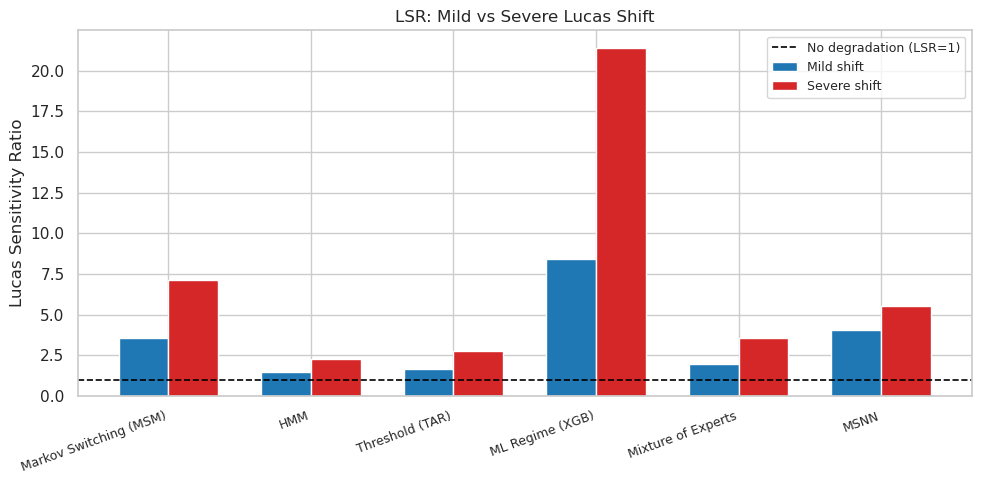

In [15]:
# Merged comparison
merged = (
    summary[['model', 'LSR']].rename(columns={'LSR': 'LSR_mild'})
    .merge(results_severe.summary[['model', 'LSR']].rename(columns={'LSR': 'LSR_severe'}), on='model')
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(merged))
width = 0.35
ax.bar(x - width/2, merged['LSR_mild'], width, label='Mild shift', color='#1f77b4')
ax.bar(x + width/2, merged['LSR_severe'], width, label='Severe shift', color='#d62728')
ax.axhline(1.0, color='black', ls='--', lw=1.2, label='No degradation (LSR=1)')
ax.set_xticks(x)
ax.set_xticklabels(merged['model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Lucas Sensitivity Ratio')
ax.set_title('LSR: Mild vs Severe Lucas Shift')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, '03_mild_vs_severe_lsr')
plt.show()

## 7. Interpretation

In [17]:
best_mild = results.best_model('LSR')
best_severe = results_severe.best_model('LSR')
worst_mild = summary.sort_values('LSR', ascending=False).iloc[0]['model']

print('Key findings:')
print(f'  Under mild shift  — most Lucas-stable model: {best_mild}')
print(f'  Under severe shift — most Lucas-stable model: {best_severe}')
print(f'  Worst (most Lucas-vulnerable, mild shift): {worst_mild}')
print()
print('Discussion:')
print('''  The Lucas Sensitivity Ratio measures how much a model's forecast
  performance degrades once the DGP parameters shift.  Classical models
  (Markov Switching, TAR) fix their parameters at estimation time, making
  them inherently brittle to structural change.  ML models (XGBoost regime
  switcher, Mixture of Experts) may show lower LSR if their learned
  representations are robust to moderate parameter drift — but they are
  not immune.  Under a severe shift, the clusters and gating functions
  fitted to the pre-break regime structure become equally outdated.

  This experiment illustrates that the Lucas Critique is a fundamental
  epistemic problem, not purely a modelling artefact: any model that learns
  from historical data is susceptible when the structural environment changes.''')

Key findings:
  Under mild shift  — most Lucas-stable model: HMM
  Under severe shift — most Lucas-stable model: HMM
  Worst (most Lucas-vulnerable, mild shift): ML Regime (XGB)

Discussion:
  The Lucas Sensitivity Ratio measures how much a model's forecast
  performance degrades once the DGP parameters shift.  Classical models
  (Markov Switching, TAR) fix their parameters at estimation time, making
  them inherently brittle to structural change.  ML models (XGBoost regime
  switcher, Mixture of Experts) may show lower LSR if their learned
  representations are robust to moderate parameter drift — but they are
  not immune.  Under a severe shift, the clusters and gating functions
  fitted to the pre-break regime structure become equally outdated.

  This experiment illustrates that the Lucas Critique is a fundamental
  epistemic problem, not purely a modelling artefact: any model that learns
  from historical data is susceptible when the structural environment changes.


## 8. Save Final Results

In [18]:
data_dir = PROJECT_ROOT / 'data' / 'simulated'
results.summary.to_csv(data_dir / 'lucas_critique_mild.csv', index=False)
results_severe.summary.to_csv(data_dir / 'lucas_critique_severe.csv', index=False)
merged.to_csv(data_dir / 'lucas_critique_comparison.csv', index=False)
print('Results saved.')

Results saved.
